### Analyse du jeu de données : 

  Famille d'emploi  Dernière promotion (mois)  Dernière augmentation (mois)  \
0       Production                   8.510000                      7.900000   
1       Production                  35.119999                     22.690001   
2       Production                  25.299999                     22.139999   
3       Production                   5.240000                      5.100000   
4       Production                  35.919998                     22.840000   

   Début de contrat (années)  Ancienneté groupe (années)  Etablissement  \
0                   0.910000                    0.970000             27   
1                  14.830000                   16.299999              7   
2                  17.309999                   17.790001             28   
3                   1.020000                    1.750000             27   
4                   8.050000                    9.000000              7   

   Âge (années)  Parent  Niveau hiérarchique  Salaire (Euros) Statut marit

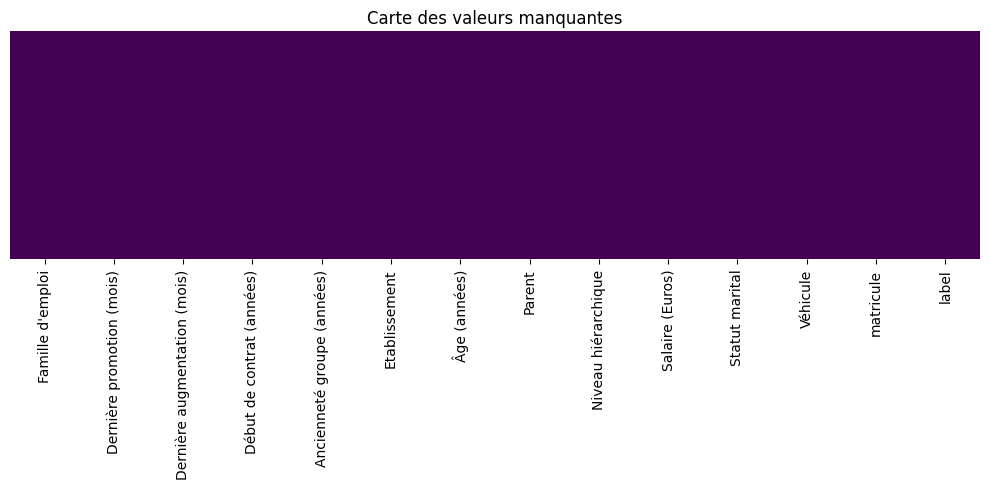

       Dernière promotion (mois)  Dernière augmentation (mois)  \
count               23857.000000                  23857.000000   
mean                   29.460739                      7.934986   
std                    25.497874                      7.549982   
min                     0.000000                      0.000000   
25%                    10.590000                      3.180000   
50%                    21.219999                      5.880000   
75%                    41.400002                     10.340000   
max                   152.970001                     84.050003   

       Début de contrat (années)  Ancienneté groupe (années)  Etablissement  \
count               23857.000000                23857.000000   23857.000000   
mean                    7.530322                   11.632095      20.193947   
std                     5.985476                    9.218618       9.295469   
min                     0.000000                    0.000000       0.000000   
25%       

C:\Users\celes\AppData\Local\Temp\ipykernel_46460\316536398.py:37: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))  # variables catégorielles
C:\Users\celes\AppData\Local\Temp\ipykernel_46460\316536398.py:43: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/us

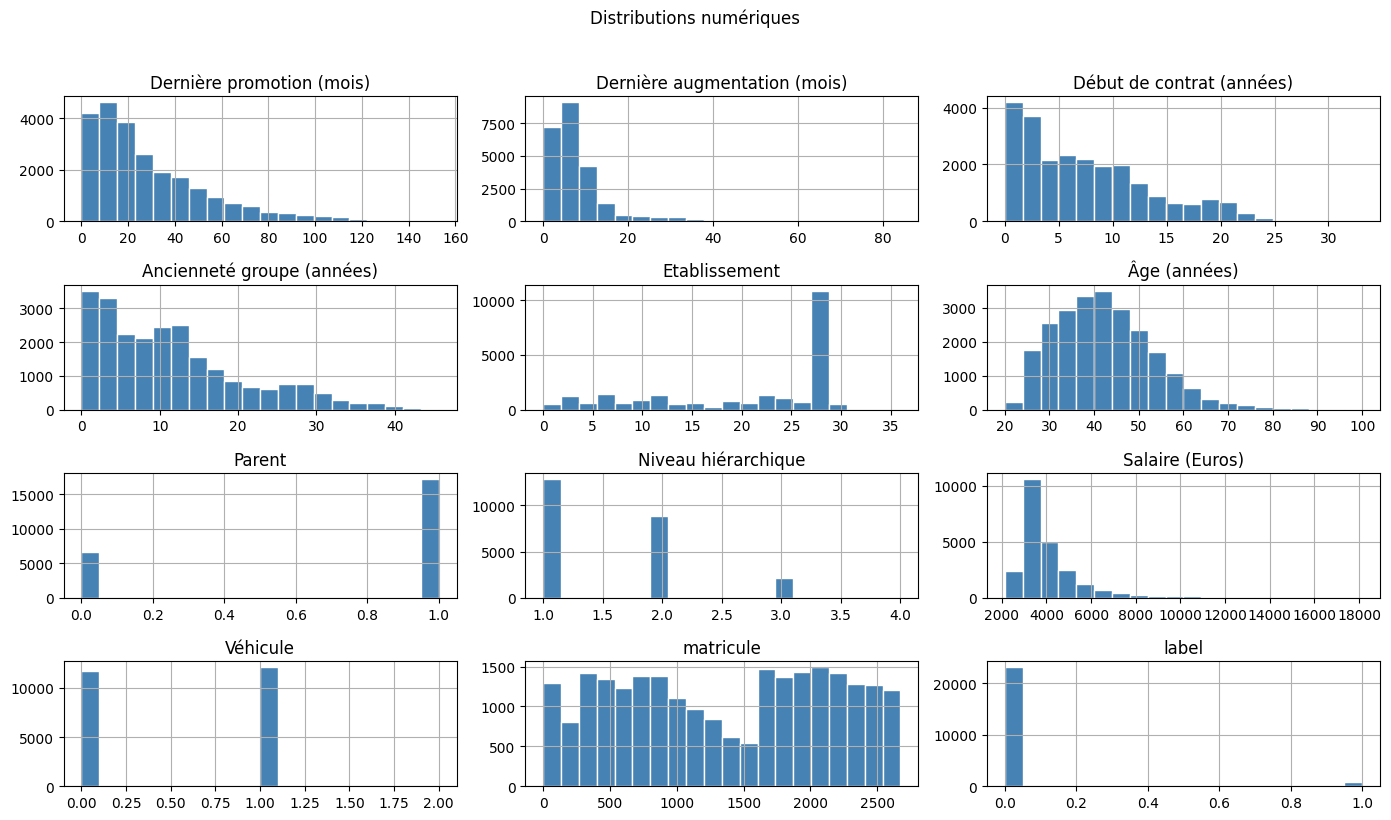

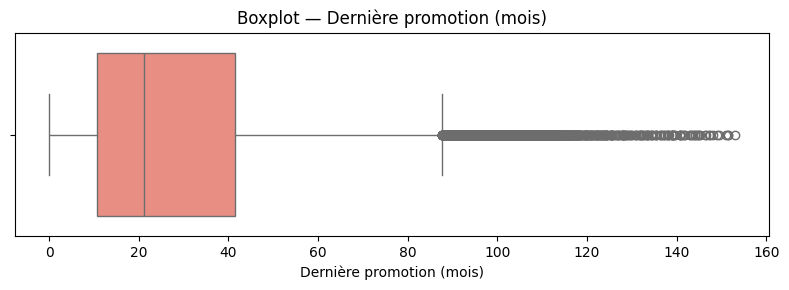

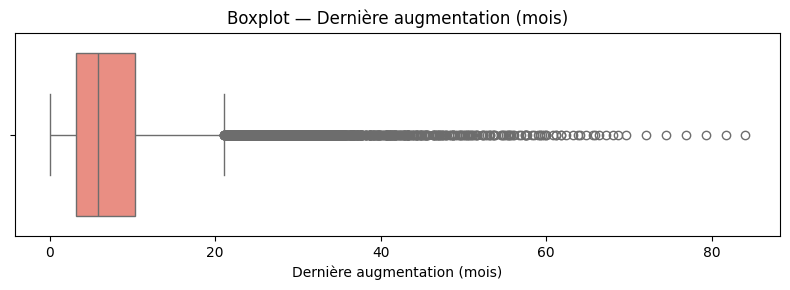

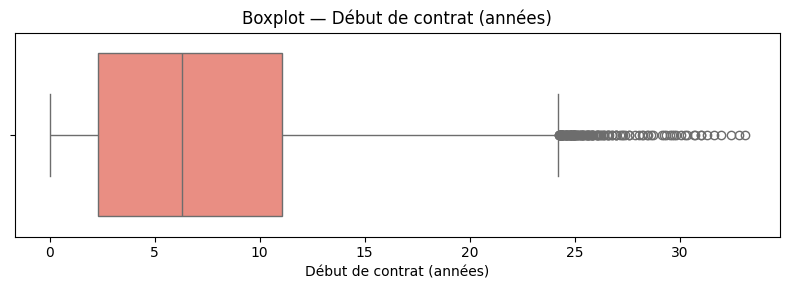

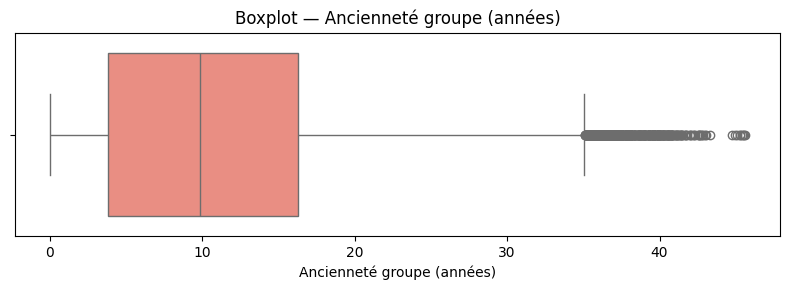

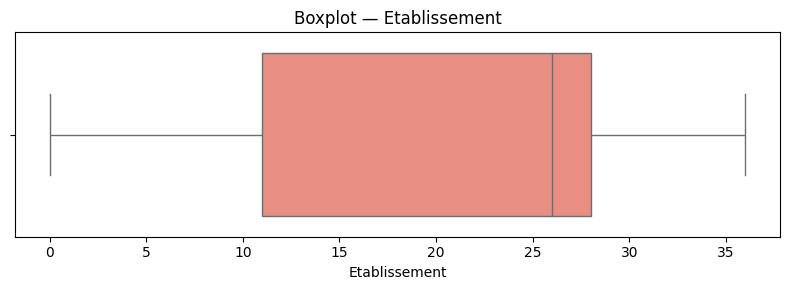

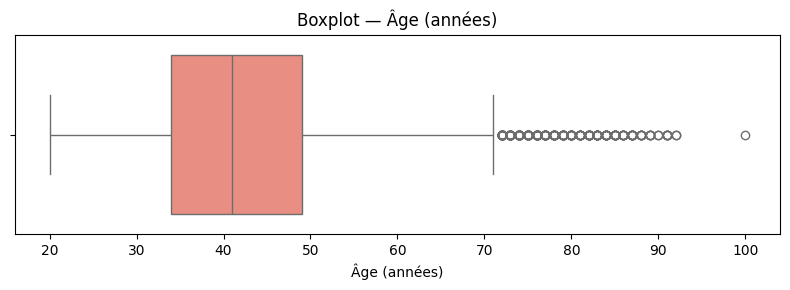

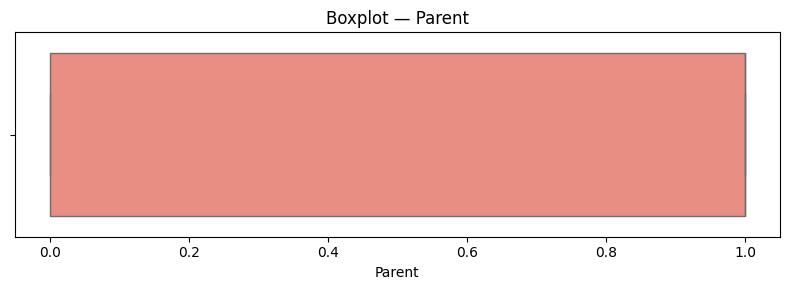

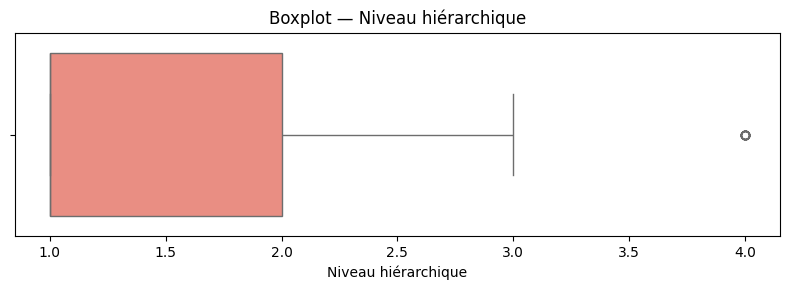

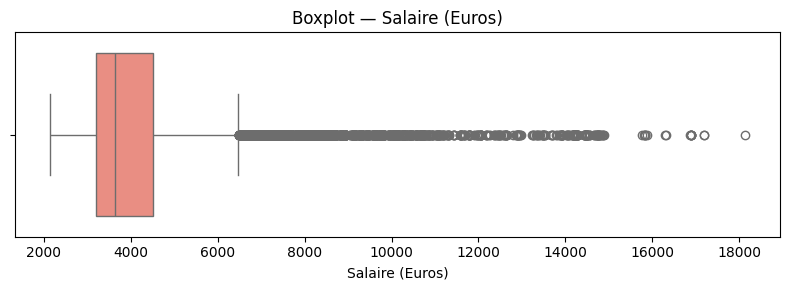

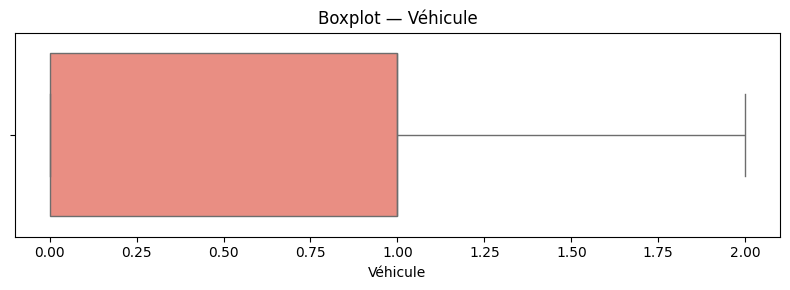

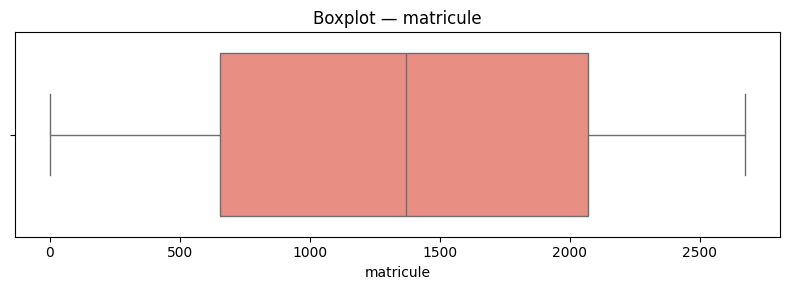

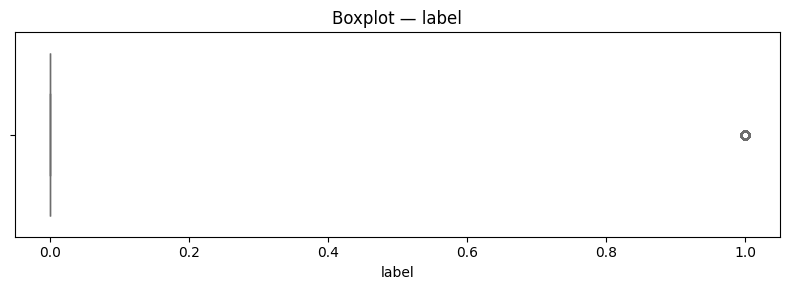

C:\Users\celes\AppData\Local\Temp\ipykernel_46460\316536398.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


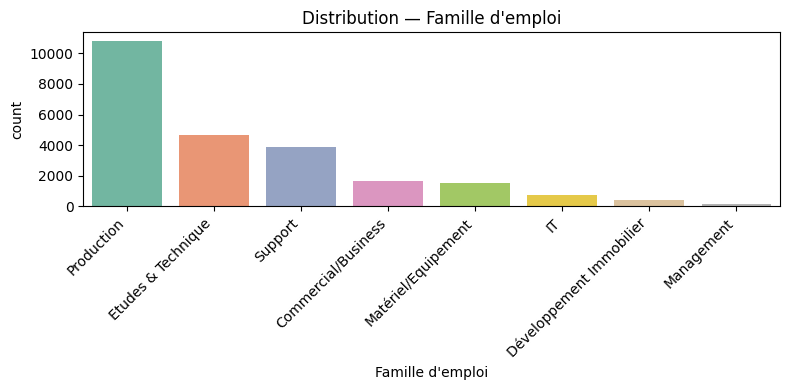

C:\Users\celes\AppData\Local\Temp\ipykernel_46460\316536398.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")


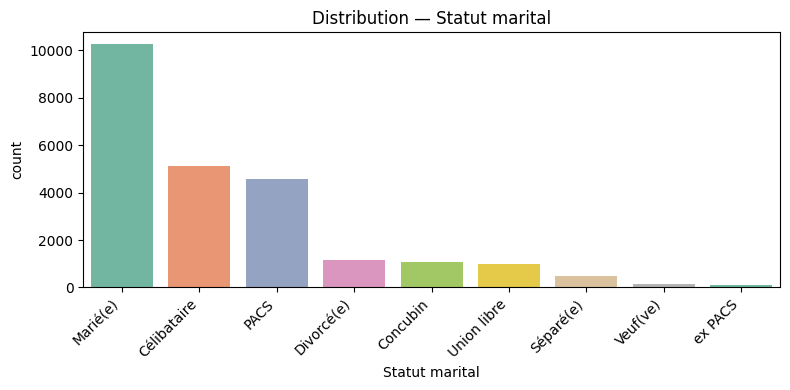

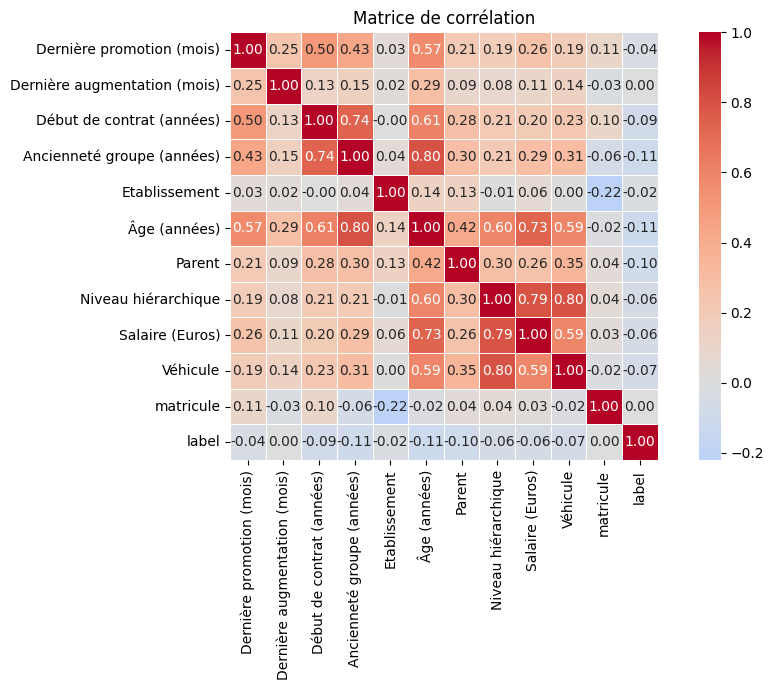

     Dernière promotion (mois)  Dernière augmentation (mois)  \
min                   0.000000                      0.000000   
max                 152.970001                     84.050003   

     Début de contrat (années)  Ancienneté groupe (années)  Etablissement  \
min                   0.000000                    0.000000              0   
max                  33.119999                   45.619999             36   

     Âge (années)  Parent  Niveau hiérarchique  Salaire (Euros)  Véhicule  \
min            20       0                    1             2134         0   
max           100       1                    4            18137         2   

     matricule  label  
min          0      0  
max       2675      1  


In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 0. CHARGEMENT DU DATASET
# ============================================================
df = pd.read_csv("RH_dataset.csv", sep=";", encoding="utf-8")  # adapter le séparateur et l'encodage si besoin

# ============================================================
# 1. APERÇU GÉNÉRAL
# ============================================================
print(df.head())           # premières lignes
print(df.shape)            # (nb_lignes, nb_colonnes)
print(df.dtypes)           # type de chaque colonne
print(df.info())           # résumé complet


# ============================================================
# 2. DONNÉES MANQUANTES
# ============================================================
print("donnes manquantes :")
print(df.isnull().sum())                            # nb de NaN par colonne
print((df.isnull().sum() / len(df) * 100).round(2)) # en pourcentage

# Heatmap des valeurs manquantes
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap="viridis", yticklabels=False)
plt.title("Carte des valeurs manquantes")
plt.tight_layout(); plt.show()


# ============================================================
# 3. STATISTIQUES DESCRIPTIVES
# ============================================================
print(df.describe())                  # variables numériques
print(df.describe(include="object"))  # variables catégorielles


# ============================================================
# 4. CARDINALITÉ & MODALITÉS (colonnes catégorielles)
# ============================================================
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print(f"\n--- {col} ---")
    print(f"  Cardinal : {df[col].nunique()}")
    print(f"  Modalités : {df[col].unique()[:20]}")
    print(df[col].value_counts())


# ============================================================
# 5. DISTRIBUTIONS — variables numériques
# ============================================================
num_cols = df.select_dtypes(include="number").columns

#verifier les types et l'allure des donnéess
print("Types de données :")
print(df.dtypes)          # vérifier les types actuels
print(df.head(3))         # voir l'allure des données brutes

# Histogrammes
df[num_cols].hist(figsize=(14, 8), bins=20, color="steelblue", edgecolor="white")
plt.suptitle("Distributions numériques", y=1.02)
plt.tight_layout(); plt.show()

# Boxplots (outliers)
for col in num_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col], color="salmon")
    plt.title(f"Boxplot — {col}")
    plt.tight_layout(); plt.show()


# ============================================================
# 6. DISTRIBUTIONS — variables catégorielles
# ============================================================
for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="Set2")
    plt.title(f"Distribution — {col}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout(); plt.show()


# ============================================================
# 7. MATRICE DE CORRÉLATION
# ============================================================
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, square=True, linewidths=0.5)
plt.title("Matrice de corrélation")
plt.tight_layout(); plt.show()


# ============================================================
# 8. PAIRPLOT  (décommenter si peu de colonnes)
# ============================================================
# sns.pairplot(df, hue="NOM_COLONNE_CIBLE")
# plt.show()


# ============================================================
# 9. PLAGES DE VALEURS
# ============================================================
print(df[num_cols].agg(["min", "max"]))

### Analyse de la matrice de corrélation

